In [1]:
!pip install -Uqq fastbook
!pip install --upgrade ipywidgets jupyterlab_widgets
!pip install voila
!jupyter serverextension enable --sys-prefix voila 

import io
from PIL import Image as PILImage
import ipywidgets as widgets
from fastai.vision.widgets import *
from fastai.vision.all import *
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import io
from IPython.display import display, clear_output


for dirname, _, filenames in os.walk('dataset'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

  Using cached ipywidgets-8.1.8-py3-none-any.whl.metadata (2.4 kB)
  Using cached jupyterlab_widgets-3.0.16-py3-none-any.whl.metadata (20 kB)
  Using cached widgetsnbextension-4.0.15-py3-none-any.whl.metadata (1.6 kB)
Using cached ipywidgets-8.1.8-py3-none-any.whl (139 kB)
Using cached jupyterlab_widgets-3.0.16-py3-none-any.whl (914 kB)
Using cached widgetsnbextension-4.0.15-py3-none-any.whl (2.2 MB)
  Attempting uninstall: widgetsnbextension
    Found existing installation: widgetsnbextension 3.6.10
    Uninstalling widgetsnbextension-3.6.10:
      Successfully uninstalled widgetsnbextension-3.6.10
  Attempting uninstall: jupyterlab_widgets
    Found existing installation: jupyterlab_widgets 1.1.11
    Uninstalling jupyterlab_widgets-1.1.11:
      Successfully uninstalled jupyterlab_widgets-1.1.11
  Attempting uninstall: ipywidgets
    Found existing installation: ipywidgets 7.8.5
    Uninstalling ipywidgets-7.8.5:
      Successfully uninstalled ipywidgets-7.8.5
   ━━━━━━━━━━━━━━━━━━━

Step 1: Scanning files in dataset/bears...
Found 288 images.
Step 2: Defining DataBlock transforms...
Step 3: Loading dataloaders (this may take a moment)...
SUCCESS: Dataloaders created!
Training batches: 3, Validation batches: 1
Step 4: Batch display successful.


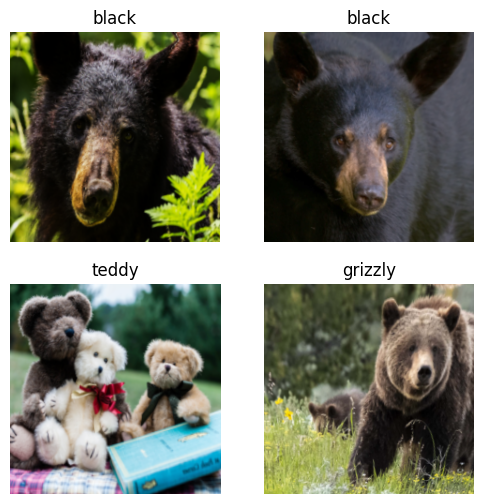

In [ ]:
# training step don't need to run again, but you can run it if you want to retrain the model. Just make sure to comment it out before running the bearrecognizer.ipynb file
# import os
# from pathlib import Path
# from fastai.vision.all import *

# # 1. Set path
# path = Path('dataset/bears')

# if not path.exists():
#     print(f"ERROR: The path {path} does not exist! Check your GitHub folder structure.")
# else:
#     print(f"Step 1: Scanning files in {path}...")
#     fns = get_image_files(path)
#     print(f"Found {len(fns)} images.")

#     # 2. Define the DataBlock ONCE with all transformations
#     print("Step 2: Defining DataBlock transforms...")
#     bears = DataBlock(
#         blocks=(ImageBlock, CategoryBlock), 
#         get_items=get_image_files, 
#         splitter=RandomSplitter(valid_pct=0.2, seed=42),
#         get_y=parent_label,
#         # Combine all transforms here to avoid running it twice
#         item_tfms=RandomResizedCrop(224, min_scale=0.5),
#         batch_tfms=aug_transforms()
#     )

#     # 3. Load the dataloaders (The heavy lifting)
#     print("Step 3: Loading dataloaders (this may take a moment)...")
#     try:
#         dls = bears.dataloaders(path)
#         print("SUCCESS: Dataloaders created!")
#         print(f"Training batches: {len(dls.train)}, Validation batches: {len(dls.valid)}")
#     except Exception as e:
#         print(f"FAILED during dataloader creation: {e}")

#     # 4. Verify with a quick display
#     try:
#         dls.show_batch(max_n=4)
#         print("Step 4: Batch display successful.")
#     except Exception as e:
#         print(f"Error displaying batch: {e}")


In [ ]:
#  run this again if you want to retrain the model, but make sure to comment it out before running the bearrecognizer.ipynb file
# learn = vision_learner(dls, resnet18, metrics=error_rate)
# learn.fine_tune(4)
# learn.export()

epoch,train_loss,valid_loss,error_rate,time
0,1.313423,0.461485,0.175439,00:05


epoch,train_loss,valid_loss,error_rate,time
0,0.344344,0.184555,0.052632,00:05
1,0.226917,0.146869,0.035088,00:05
2,0.179699,0.119270,0.035088,00:05
3,0.137959,0.100516,0.035088,00:06


In [ ]:

# Check that the file exist

[Path('export.pkl')]

In [10]:
path = Path()
path.ls(file_exts='.pkl')
learn_inf = load_learner(path/'export.pkl')

In [8]:
import io
import os
from PIL import Image as PILImage # Keep this for display purposes
import ipywidgets as widgets
from fastai.vision.all import *
from IPython.display import display, clear_output

# --- ASSUMING YOU ALREADY HAVE YOUR MODEL LOADED ---
# learn_inf = load_learner('model.pkl') 


# 1. Create the UI elements
btn_upload = widgets.FileUpload(accept='image/*', multiple=False)
output_area = widgets.Output() 

# 2. Define the Handler
def handle_upload(change):
    """
    This function is triggered automatically when 'btn_upload.value' changes.
    """
    with output_area:
        clear_output() 
        
        if not btn_upload.value:
            print("No file uploaded yet.")
            return

        try:
            print("Processing new upload...")
            
            # A. Extract bytes from the widget
            # Note: In newer ipywidgets, value is a tuple of dicts
            uploaded_file = btn_upload.value[0]
            image_bytes = uploaded_file['content']

            # B. FIX THE ERROR HERE: 
            # Use PILImage.create (Fastai way) instead of .open (Pillow way)
            # We wrap the bytes in BytesIO so Fastai can read them like a file
            img = PILImage.create(io.BytesIO(image_bytes))

            # C. Save to disk 
            # Use a relative path so it works on Binder, Kaggle, or Local
            temp_path = "temp_image.jpg" 
            with open(temp_path, "wb") as f:
                f.write(image_bytes)

            # D. Run Inference
            pred, pred_idx, probs = learn_inf.predict(temp_path)

            # E. Display the results to the user
            print("-" * 30)
            print(f"PREDICTION: {pred}")
            print(f"CONFIDENCE: {probs[pred_idx]:.2%}")
            print("-" * 30)
            display(img)

        except Exception as e:
            print(f"An error occurred during prediction: {e}")
            # This will help you debug if something else goes wrong
            import traceback
            traceback.print_exc()

# 3. The "Magic" Link (The Observer)
btn_upload.observe(handle_upload, names='value')

# 4. Display everything to the user
print("AI Image Classifier App")
print("Click the button below to upload an image:")
display(btn_upload)
display(output_area)


AI Image Classifier App
Click the button below to upload an image:


FileUpload(value=(), accept='image/*', description='Upload')

Output()